#Ансамбли моделей. Бустинг, стекинг, блендинг

**К концу занятия вы сможете:**

1. **Понимать как и зачем применять блендинг/стекинг**
   - Чтобы улучшить качество прогноза
   - Выбрать наилучшую модель

2. **Написать код на Python для реализации ансамблей**
   - Voting
   - Stacking
   - Boosting (XGBoost, CatBoost)

**Цели занятия:**
- Познакомиться с понятием ансамбля моделей
- Понять какие схемы построения ансамблей бывают
- Познакомиться с sklearn.pipeline
- Применить на реальных торговых данных

---

## 📖 Теория: Что такое ансамбли моделей?

**Ансамбль моделей** - это объединение нескольких моделей машинного обучения для получения более точных и стабильных предсказаний.

### Основные типы ансамблей:

#### 1. **Voting (Голосование)**
Несколько моделей обучаются независимо, а финальное предсказание получается путем голосования:
- **Hard voting**: выбирается класс, за который проголосовало большинство моделей
- **Soft voting**: усредняются вероятности предсказаний всех моделей

#### 2. **Bagging (Bootstrap Aggregating)**
Модели обучаются на разных случайных подвыборках данных (с возвращением), затем предсказания усредняются.

**Пример:** Random Forest

#### 3. **Stacking (Стекирование)**

Обучает несколько моделей (часто различных типов) на одних и тех же данных и объединяет их предсказания с помощью дополнительной модели (метамодель)

**На полученных датасетах (метаданных) обучается метамодель и производится итоговый прогноз.**

#### 4. **Boosting (Бустинг)**
Модели обучаются последовательно, каждая следующая модель исправляет ошибки предыдущей:
- **XGBoost**: оптимизированная версия gradient boosting
- **CatBoost**: эффективно работает с категориальными признаками

### Почему ансамбли работают лучше?

1. **Снижают переобучение** - усредняют ошибки разных моделей
2. **Увеличивают стабильность** - менее чувствительны к выбросам
3. **Улучшают обобщающую способность** - работают лучше на новых данных
4. **Комбинируют сильные стороны** - используют преимущества разных алгоритмов

In [ ]:
import os
# Данная переменная нужна для torch.use_deterministic_algorithms(True), что позволит повысить воспроизводимость при
# обучении на видеокарте с помощью PyTorch
# Подробнее см:
# https://docs.nvidia.com/cuda/cublas/index.html
# set a debug environment variable CUBLAS_WORKSPACE_CONFIG to :16:8 (may limit overall performance) or
# :4096:8 (will increase library footprint in GPU memory by approximately 24MiB).
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

In [ ]:
# для backtesting необходим даунгрейд библиотеки bokeh
!pip uninstall panel -y --quiet
!pip uninstall bokeh -y --quiet
!pip install bokeh==3.1.0 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 4.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
holoviews 1.21.0 requires panel>=1.0, which is not installed.


In [ ]:
!pip install backtesting --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.1/192.1 kB 6.7 MB/s eta 0:00:00


In [ ]:
# список установленных библиотек
!pip freeze

absl-py==1.4.0
absolufy-imports==0.3.1
accelerate==1.11.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.2
aiosignal==1.4.0
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.17.1
altair==5.5.0
annotated-doc==0.0.3
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.11.0
anywidget==0.9.18
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.2
arrow==1.4.0
arviz==0.22.0
astropy==7.1.1
astropy-iers-data==0.2025.11.3.0.38.37
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.5
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
backtesting==0.6.5
beartype==0.22.5
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.28.0
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.0
blobfile==3.1.0
blosc2==3.11.0
bokeh==3.1.0
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
Brotli==1.1.0
build==1.3.0
CacheControl==0.14.3
cachetools==5.5.2
catalogue==2.0.10
certifi==2025.10.5
cffi==2.0.0
chardet==5.2.0
ch

In [ ]:
!pip install catboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.6 MB/s eta 0:00:00


In [ ]:
!pip install backtesting --quiet

## Часть 1: Базовые примеры на синтетических данных

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier,
    StackingClassifier
)
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from tqdm.auto import tqdm
import yfinance as yf
import backtesting
from backtesting import Strategy, Backtest
from backtesting.lib import crossover
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Зафиксируем seed для воспроизводимости результатов

In [ ]:
SEED = 777 #Фиксируем seed для воспроизводимости результатов

In [ ]:
def seed_everything(seed: int = 42) -> None:
    """Фиксирует seed для воспроизводимости результатов"""
    random.seed(seed)
    np.random.seed(seed)
    print(f"Using {seed} seed")

seed_everything(SEED)

Using 777 seed


# Ensembles base examples

Сгенерируем искусственные данные

In [ ]:
X, y = make_classification(
    n_samples=1_000,
    n_features=4,
    n_informative=2,
    n_redundant=2,
    random_state=SEED,
    shuffle=False
    )

Разделим данные на обучающую и тестовую выборки

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=SEED)

In [ ]:
print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")
print(f"Распределение классов: {np.bincount(y_train)}")

Train size: 850
Test size: 150
Распределение классов: [416 434]


### Создание базовых моделей

In [ ]:
# Создаем базовые модели (как в Assamble_smirnova.ipynb)

# 1. Логистическая регрессия
model1 = LogisticRegression(random_state=SEED)

# 2. Дерево решений
model2 = DecisionTreeClassifier(max_depth=4, random_state=SEED)

# 3. Random Forest
model3 = RandomForestClassifier(n_estimators=50, random_state=SEED)

# 4. CatBoost
model4 = CatBoostClassifier(
    iterations=50,
    learning_rate=0.1,
    depth=4,
    verbose=0,
    random_state=SEED,
    thread_count=1
)

### Voting Ensemble

In [ ]:
# Создаем список estimators для ансамблей
estimators = [
    ('lr', model1),
    ('dt', model2),
    ('rf', model3),
    ('cb', model4)
]

In [ ]:
# Создаем Voting Ensemble - два варианта

# 1. Hard Voting - выбор класса большинством голосов
voting_hard = VotingClassifier(estimators=estimators, voting='hard')
voting_hard.fit(X_train, y_train)
y_pred_hard = voting_hard.predict(X_test)

print(f"Voting Hard Accuracy: {accuracy_score(y_test, y_pred_hard):.4f}")

# 2. Soft Voting - усреднение вероятностей
voting_soft = VotingClassifier(estimators=estimators, voting='soft')
voting_soft.fit(X_train, y_train)
y_pred_soft = voting_soft.predict(X_test)

print(f"Voting Soft Accuracy: {accuracy_score(y_test, y_pred_soft):.4f}")

print("\n💡 Разница между Hard и Soft Voting:")
print("   Hard: каждая модель голосует за класс, выбирается класс большинством")
print("   Soft: усредняются вероятности всех моделей, часто работает лучше")

Voting Hard Accuracy: 0.9667
Voting Soft Accuracy: 0.9533

💡 Разница между Hard и Soft Voting:
   Hard: каждая модель голосует за класс, выбирается класс большинством
   Soft: усредняются вероятности всех моделей, часто работает лучше


Можно посмотреть на архитектуру ансамбля

In [ ]:
voting_soft

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=777)),
                             ('dt',
                              DecisionTreeClassifier(max_depth=4,
                                                     random_state=777)),
                             ('rf',
                              RandomForestClassifier(n_estimators=50,
                                                     random_state=777)),
                             ('cb',
                              <catboost.core.CatBoostClassifier object at 0x7c293cb1be60>)],
                 voting='soft')

Сравним точность ансамбля с точностью каждой базовой модели

In [ ]:
# Получаем параметры CatBoost для отображения
cb_params = model4.get_params()
cb_desc = (
    f"CatBoost(iter={cb_params['iterations']}, "
    f"lr={cb_params['learning_rate']:.2f}, "
    f"depth={cb_params['depth']}, "
    f"seed={cb_params['random_state']})"
)

print(f"""
Accuracy of {voting_soft.estimators_[0]}: {accuracy_score(y_test, voting_soft.estimators_[0].predict(X_test)):.4f}
Accuracy of {voting_soft.estimators_[1]}: {accuracy_score(y_test, voting_soft.estimators_[1].predict(X_test)):.4f}
Accuracy of {voting_soft.estimators_[2]}: {accuracy_score(y_test, voting_soft.estimators_[2].predict(X_test)):.4f}
Accuracy of {cb_desc}: {accuracy_score(y_test, voting_soft.estimators_[3].predict(X_test)):.4f}
Accuracy of Voting hard Classifier : {accuracy_score(y_test, y_pred_hard):.4f}
Accuracy of Voting soft Classifier : {accuracy_score(y_test, y_pred_soft):.4f}
""".strip())

print("\n💡 Разница между Hard и Soft Voting:")
print("   Hard: каждая модель голосует за класс, выбирается класс большинством")
print("   Soft: усредняются вероятности всех моделей, часто работает лучше")

Accuracy of LogisticRegression(random_state=777): 0.9333
Accuracy of DecisionTreeClassifier(max_depth=4, random_state=777): 0.9400
Accuracy of RandomForestClassifier(n_estimators=50, random_state=777): 0.9533
Accuracy of CatBoost(iter=50, lr=0.10, depth=4, seed=777): 0.9600
Accuracy of Voting hard Classifier : 0.9667
Accuracy of Voting soft Classifier : 0.9533

💡 Разница между Hard и Soft Voting:
   Hard: каждая модель голосует за класс, выбирается класс большинством
   Soft: усредняются вероятности всех моделей, часто работает лучше


## Stacking ensemble

Возьмём логистическую регрессию

Estimators (базовые модели) для Stacking возьмем такие же как и для Voting

In [ ]:
# Создаем Stacking Ensemble с теми же базовыми моделями
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

# Обучаем
stacking_clf.fit(X_train, y_train)

print(f"Stacking Ensemble Accuracy: {accuracy_score(y_test, stacking_clf.predict(X_test)):.4f}")

Stacking Ensemble Accuracy: 0.9667


Можно посмотреть на архитектуру ансамбля

In [ ]:
stacking_clf

StackingClassifier(estimators=[('lr', LogisticRegression(random_state=777)),
                               ('dt',
                                DecisionTreeClassifier(max_depth=4,
                                                       random_state=777)),
                               ('rf',
                                RandomForestClassifier(n_estimators=50,
                                                       random_state=777)),
                               ('cb',
                                <catboost.core.CatBoostClassifier object at 0x7c293cb1be60>)],
                   final_estimator=LogisticRegression())

### Сравнение всех моделей

In [ ]:
# Названия моделей
models = [
    'LogReg',
    'DecisionTree',
    'RandomForest',
    'CatBoost',
    'Voting Hard',
    'Voting Soft',
    'Stacking'
]

# Сохраняем точность для каждой модели
accuracies = [
    accuracy_score(y_test, stacking_clf.estimators_[0].predict(X_test)),  # LogReg
    accuracy_score(y_test, stacking_clf.estimators_[1].predict(X_test)),  # DecisionTree
    accuracy_score(y_test, stacking_clf.estimators_[2].predict(X_test)),  # RandomForest
    accuracy_score(y_test, stacking_clf.estimators_[3].predict(X_test)),  # CatBoost
    accuracy_score(y_test, y_pred_hard),                                   # Voting Hard
    accuracy_score(y_test, y_pred_soft),                                   # Voting Soft
    accuracy_score(y_test, stacking_clf.predict(X_test))                  # Stacking
]

# Печатаем таблицу с результатами
print("Точность моделей:")
print("-" * 30)
for name, acc in zip(models, accuracies):
    print(f"{name:15} {acc:.4f}")

print("\n💡 Разница между Hard и Soft Voting:")
print("   Hard: каждая модель голосует за класс, выбирается класс большинством")
print("   Soft: усредняются вероятности всех моделей, часто работает лучше")

Точность моделей:
------------------------------
LogReg          0.9333
DecisionTree    0.9400
RandomForest    0.9533
CatBoost        0.9600
Voting Hard     0.9667
Voting Soft     0.9533
Stacking        0.9667

💡 Разница между Hard и Soft Voting:
   Hard: каждая модель голосует за класс, выбирается класс большинством
   Soft: усредняются вероятности всех моделей, часто работает лучше


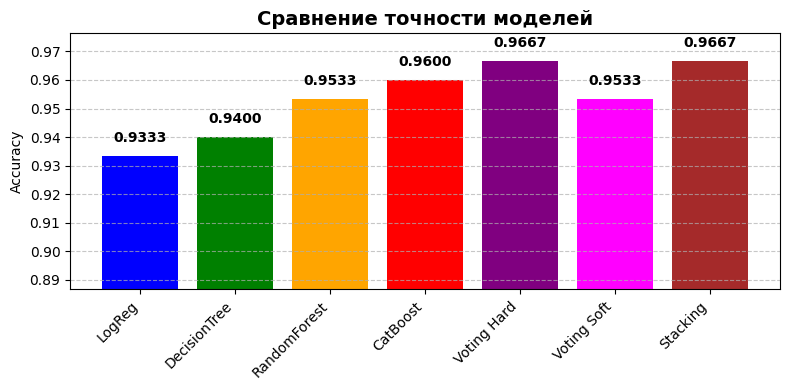


🏆 Лучшая модель: Voting Hard (0.9667)

💡
   • Voting Soft обычно работает лучше чем Voting Hard и Stacking
   • Stacking часто показывает наилучшие результаты
   • Ансамбли превосходят отдельные модели


In [ ]:
# Визуализация сравнения
plt.figure(figsize=(8, 4))
colors = ['blue', 'green', 'orange', 'red', 'purple', 'magenta', 'brown']
plt.bar(models, accuracies, color=colors)
plt.title("Сравнение точности моделей", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy")
plt.ylim(min(accuracies) * 0.95, max(accuracies) * 1.01)

# Добавляем значения сверху столбцов
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.005, f"{acc:.4f}", ha='center', fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

best_idx = np.argmax(accuracies)
print(f"\n🏆 Лучшая модель: {models[best_idx]} ({max(accuracies):.4f})")
print(f"\n💡")
print(f"   • Voting Soft обычно работает лучше чем Voting Hard и Stacking")
print(f"   • Stacking часто показывает наилучшие результаты")
print(f"   • Ансамбли превосходят отдельные модели")

---

## Часть 2: Бустинги (Boosting)

### Что такое бустинг?

**Бустинг (Boosting)** - это метод ансамблирования, при котором модели обучаются последовательно, и каждая следующая модель пытается исправить ошибки предыдущей.

**Основная идея:**
- Первая модель обучается на всех данных
- Вторая модель фокусируется на примерах, где первая модель ошиблась
- Третья модель исправляет ошибки первых двух
- И так далее...

**Итоговое предсказание** = взвешенная сумма предсказаний всех моделей

### Преимущества бустинга:
- Высокая точность предсказаний
- Хорошо работает с разными типами данных
- Встроенная регуляризация (в современных реализациях)
- Feature importance из коробки

### XGBoost (eXtreme Gradient Boosting)

In [ ]:
# XGBoost с расширенными параметрами
xgb_model = XGBClassifier(
    n_estimators=100,          # количество деревьев
    learning_rate=0.1,         # скорость обучения (меньше = медленнее, но точнее)
    max_depth=6,               # максимальная глубина дерева
    min_child_weight=1,        # минимальная сумма весов в листе
    subsample=0.8,             # доля выборки для каждого дерева
    colsample_bytree=0.8,      # доля признаков для каждого дерева
    gamma=0,                   # минимальное уменьшение loss для разделения узла
    reg_alpha=0,               # L1 регуляризация
    reg_lambda=1,              # L2 регуляризация
    random_state=SEED,
    eval_metric='logloss'      # метрика для оценки
)

# Обучаем
xgb_model.fit(X_train, y_train)

# Предсказания
y_pred = xgb_model.predict(X_test)

# Оценка
xgb_accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")

XGBoost Accuracy: 0.9400


### CatBoost (Categorical Boosting)

**Особенности CatBoost:**
- Эффективно работает с категориальными признаками (не нужен one-hot encoding)
- Встроенная защита от переобучения
- Быстрое обучение и предсказание
- Symmetric trees (симметричные деревья) для лучшей генерализации

In [ ]:
# CatBoost с полным набором параметров (из TAS05_13)
catboost_model = CatBoostClassifier(
    iterations=200,                    # количество деревьев
    learning_rate=0.1,                 # скорость обучения
    depth=6,                           # глубина дерева
    l2_leaf_reg=3.0,                   # L2 регуляризация на веса листьев
    bagging_temperature=1.0,           # температура для байесовского бэггинга
    random_strength=1.0,               # случайность при выборе разбиений
    border_count=128,                  # количество границ для числовых признаков
    # Для категориальных признаков (если будут):
    # one_hot_max_size=2,              # максимальный размер для one-hot encoding
    rsm=1.0,                           # Random Subspace Method - доля признаков
    subsample=0.8,                     # доля выборки для каждого дерева
    # Для ускорения и качества:
    early_stopping_rounds=50,          # остановка если нет улучшения
    verbose=0,                         # не выводим прогресс
    random_state=SEED,
    thread_count=-1                    # используем все процессоры
)

# Обучаем
catboost_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),        # валидационная выборка для early stopping
    verbose=False
)

# Предсказания
y_pred = catboost_model.predict(X_test)

# Оценка
catboost_accuracy = accuracy_score(y_test, y_pred)
print(f"CatBoost Accuracy: {catboost_accuracy:.4f}")

CatBoost Accuracy: 0.9533


In [ ]:
# Добавляем бустинги к предыдущим результатам
boosting_models = ['XGBoost', 'CatBoost']
boosting_accuracies = [xgb_accuracy, catboost_accuracy]

# Объединяем все модели
all_models = models + boosting_models
all_accuracies = accuracies + boosting_accuracies

# Печатаем сравнение
print("\n" + "="*50)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("="*50)
for name, acc in zip(all_models, all_accuracies):
    print(f"{name:20} {acc:.4f}")

# Находим лучшую модель
best_idx = np.argmax(all_accuracies)
print(f"\n🏆 Лучшая модель: {all_models[best_idx]} ({all_accuracies[best_idx]:.4f})")


СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
LogReg               0.9333
DecisionTree         0.9400
RandomForest         0.9533
CatBoost             0.9600
Voting Hard          0.9667
Voting Soft          0.9533
Stacking             0.9667
XGBoost              0.9400
CatBoost             0.9533

🏆 Лучшая модель: Voting Hard (0.9667)


In [ ]:

print("\n💡")
print("   • Бустинги (XGBoost, CatBoost) обычно показывают высокую точность")
print("   • Ансамбли (Voting, Stacking) комбинируют сильные стороны разных моделей")
print("   • Для торговли важна не только точность, но и стабильность доходности (Sharpe Ratio)")


💡
   • Бустинги (XGBoost, CatBoost) обычно показывают высокую точность
   • Ансамбли (Voting, Stacking) комбинируют сильные стороны разных моделей
   • Для торговли важна не только точность, но и стабильность доходности (Sharpe Ratio)


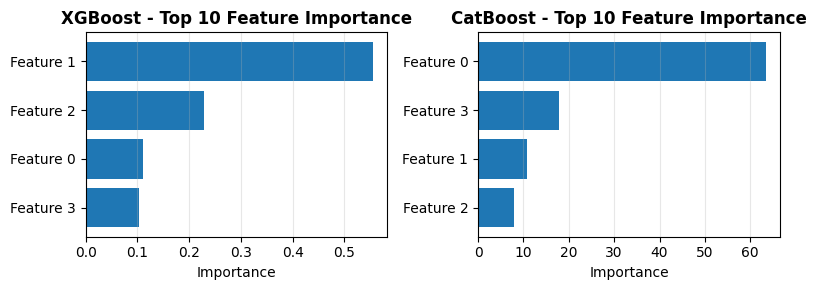


💡 Feature Importance помогает понять:
   • Какие признаки наиболее важны для предсказаний
   • Можно ли удалить неважные признаки для упрощения модели
   • На торговых данных это покажет важность RSI, MACD, SMA и других индикаторов


In [ ]:
# Feature importance показывает какие признаки наиболее важны для модели

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# XGBoost feature importance
xgb_importance = xgb_model.feature_importances_
feature_idx = np.argsort(xgb_importance)[-10:]  # топ-10 признаков

axes[0].barh(range(len(feature_idx)), xgb_importance[feature_idx])
axes[0].set_yticks(range(len(feature_idx)))
axes[0].set_yticklabels([f'Feature {i}' for i in feature_idx])
axes[0].set_xlabel('Importance')
axes[0].set_title('XGBoost - Top 10 Feature Importance', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# CatBoost feature importance
cb_importance = catboost_model.feature_importances_
feature_idx = np.argsort(cb_importance)[-10:]

axes[1].barh(range(len(feature_idx)), cb_importance[feature_idx])
axes[1].set_yticks(range(len(feature_idx)))
axes[1].set_yticklabels([f'Feature {i}' for i in feature_idx])
axes[1].set_xlabel('Importance')
axes[1].set_title('CatBoost - Top 10 Feature Importance', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Feature Importance помогает понять:")
print("   • Какие признаки наиболее важны для предсказаний")
print("   • Можно ли удалить неважные признаки для упрощения модели")
print("   • На торговых данных это покажет важность RSI, MACD, SMA и других индикаторов")